# TCLAB_CLP_PID_FF


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors

%config InlineBackend.figure_formats ="svg"
from package_DBR import *
from package_TCLAB import *
from package_LAB import *


import tclab
import time
from datetime import datetime
import os


## Simulation parameters

In [150]:
#Point de fonctionnement

MV0 = 50
PV0 = 54
DV0 = 50

#Parametre maniupulated value

Kp = 0.374684
T1_p = 171.145985
T2_p = 26.74464
theta_p = 12.00844


#Parmetre Disturbance Value

Kd = 0.3933681
T1_d= 161.75194
T2_d= 36.287948
theta_d= 19.570305



#IMC TUNING
gamma = 0.6
Kc,Ti,Td = IMC_Tuning(Kp, gamma, theta_p, T1_p, T2_p, 2)
Kc = Kc/2



alpha = 0.9
MVMin = 0
MVMax = 100
TSim = 4000
Ts = 1
N = int(TSim/Ts) + 1


print("kc = ", Kc)
print("Ti = ", Ti)
print("Td = ", Td)






kc =  2.019818032029029
Ti =  197.890625
Td =  23.13013947108611


# signals

In [151]:
scenario = "CLP+FF"



# Scenario 1: CLP + FF
if scenario == "CLP+FF":
    ManPath = {0: True, 500: False, TSim: False} 
    MVManPath = {0: MV0+10, TSim:MV0+10} 
    SPPath = {0: PV0+5, 1500: PV0-5, TSim: PV0-5} 
    DVPath = {0: DV0, 2500: DV0+20, 2800:DV0, TSim: DV0}
    ActivateFF = True
    ManFF = False


# Scenario 2: CLP + no FF
if scenario == "CLP+noFF":
    ManPath = {0: True, 500: False, TSim: False} 
    MVManPath = {0: MV0, TSim: MV0} 
    SPPath = {0: PV0+5, 1500: PV0-5, TSim: PV0-5} 
    DVPath = {0: DV0, 2500: DV0+10, TSim: DV0+10}
    ActivateFF = False
    ManFF = False


# Scenario 3: OLP + no FF
if scenario == "OLP+noFF":
    ManPath = {0: True, TSim: True}
    MVManPath = {0: MV0, TSim: MV0}
    SPPath = {0: PV0, TSim: PV0}
    DVPath = {0: 50, 1200: 60, TSim: 60}
    ActivateFF = False
    ManFF = True

# Scenario 4: OLP + FF
if scenario == "OLP+FF":
    ManPath ={0: True, TSim: True}
    MVManPath = {0: MV0, TSim: MV0}
    SPPath ={0: PV0, TSim: PV0}
    DVPath = {0: 50.0, 1200: 60, TSim: 60.0}
    ActivateFF = True
    ManFF = True



## Simulation 

In [ ]:






t = []
MV = []

MVP = []
MVI = []
MVD = []

SP=[]
MVMan=[]
MVFF = []
Man =[]
ManFF = []

DV =[]
E = []
PV = []



MVFFDelay = []
MVFFLL_output = []

MVDelayp =[]
PV1p =[]
PV2p =[]

MVDelayd =[]
PV1d =[]
PV2d =[]



lab = tclab.TCLab()

fig, (ax1, ax2, ax3) = plt.subplots(3,1)
fig.set_figheight(12)
fig.set_figwidth(22)

l1, = ax1.step([0,1],[0,100],'b-',linewidth=2,label='MV',where='post')
ax1.set_ylabel('Value of MV [%]')
ax1.set_title('Real-time test')
ax1.legend(loc='best')

l2, = ax2.step([0,1],[0,100],'g-',linewidth=2,label='PV',where='post')
ax2.set_ylabel('Value of PV [°C]')
ax2.legend(loc='best')

l3, = ax3.step([0,1],[0,100],'r-',linewidth=2,label='DV',where='post')
ax3.set_xlabel('Time [s]')
ax3.set_ylabel('Value of DV [%]')
ax3.legend(loc='best') 



# Plot

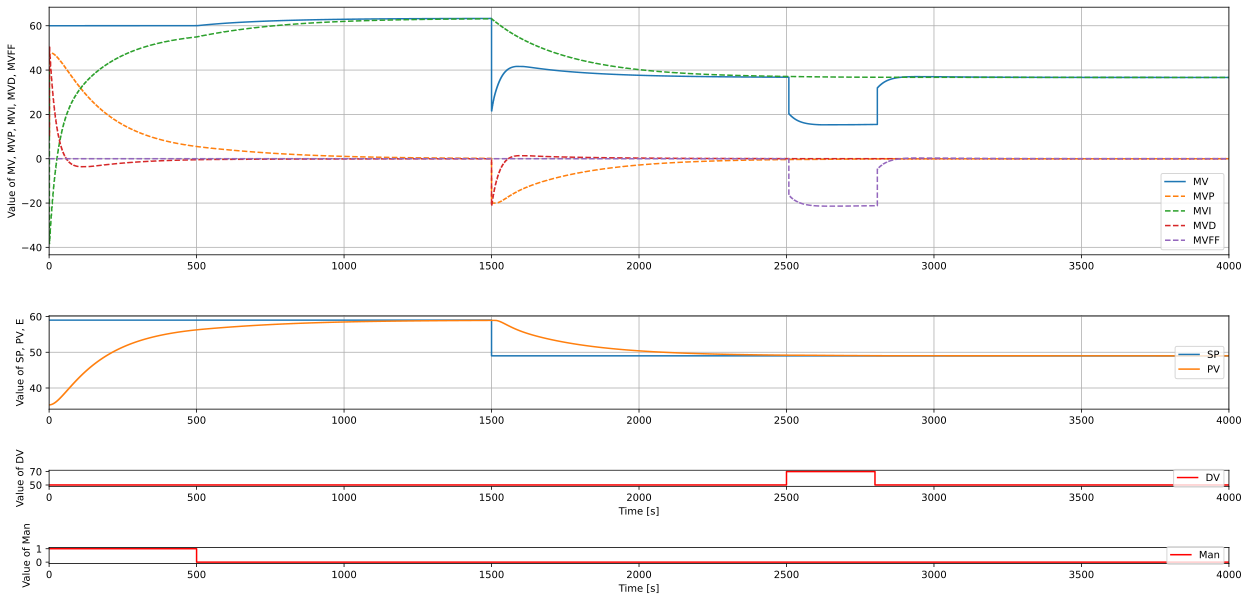

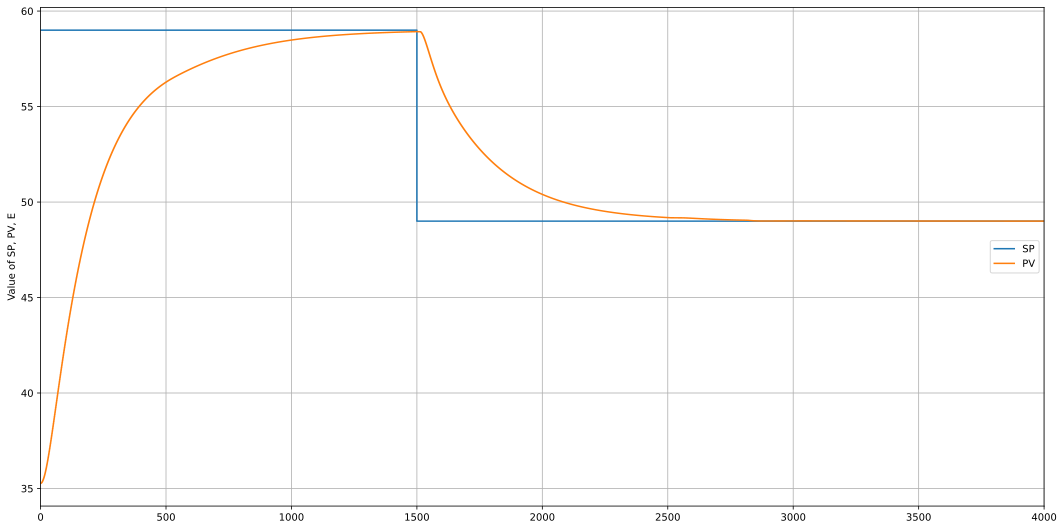

In [153]:

plt.figure(figsize = (18,9))


plt.subplot(8,1,(1,4))
plt.step(t,MV, label='MV',where='post' )
plt.step(t,MVP, label='MVP',where='post', linestyle='dashed' )
plt.step(t,MVI,label='MVI',where='post', linestyle='dashed')
plt.step(t,MVD,label='MVD',where='post', linestyle='dashed')
plt.step(t,MVFF,label='MVFF',where='post', linestyle='dashed')
# plt.step(t,MVDelay,'b-',linewidth=0.5,label='MV plus delay',where='post')
plt.ylabel('Value of MV, MVP, MVI, MVD, MVFF')
plt.legend(loc='best')
plt.xlim([0, TSim])
plt.grid()



plt.subplot(8,1,(5,6))
plt.step(t,SP, label='SP',where='post')
plt.step(t,PV, label='PV',where='post')


# plt.step(t,MVDelay,'b-',linewidth=0.5,label='MV plus delay',where='post')
plt.ylabel('Value of SP, PV, E')
plt.legend(loc='right')
plt.xlim([0, TSim])
plt.grid()


plt.subplot(8,1,7)
plt.ylim((48,72))
plt.step(t,DV,'r-',label='DV',where='post')
# plt.step(t,PV_TRAP,'springgreen',label='First order response plus delay (TRAP)',where='post')
plt.ylabel('Value of DV')
plt.xlabel('Time [s]')
plt.legend(loc='right')
plt.xlim([0, TSim])    
plt.yticks((50,70))



plt.subplot(8,1,8)
plt.ylim((-0.1,1.1))
plt.step(t,Man,'r-',label='Man',where='post')
# plt.step(t,PV_TRAP,'springgreen',label='First order response plus delay (TRAP)',where='post')
plt.ylabel('Value of Man')
plt.xlabel('Time [s]')
plt.legend(loc='right')
plt.xlim([0, TSim])  

plt.tight_layout(pad=3.0) # 'pad' defines the space around the figure edges
plt.show()



plt.figure(figsize = (18,9))
plt.step(t,SP, label='SP',where='post')
plt.step(t,PV, label='PV',where='post')


# plt.step(t,MVDelay,'b-',linewidth=0.5,label='MV plus delay',where='post')
plt.ylabel('Value of SP, PV, E')
plt.legend(loc='right')
plt.xlim([0, TSim])
plt.grid()
plt.show()





In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from IPython.display import display, clear_output
# import tclab
# import time

# # --- Paramètres de l'expérience ---
# Ts = 1            # Temps d'échantillonnage (s)
# TSim = 600        # Durée totale (s)
# Kc = 2.0          # Gain proportionnel
# Ti = 60.0         # Constante intégrale
# Td = 1.0          # Constante dérivée

# # --- Initialisation des listes de données ---
# t, PV, SP, E = [], [], [], []
# MV, MVP, MVI, MVD, MVFF = [], [], [], [], []
# Man = []

# # --- Configuration du Graphique (Structure 7 rangées) ---
# fig = plt.figure(figsize=(15, 9))

# # Subplot 1 (MV & PID)
# ax1 = plt.subplot(7, 1, (1, 4))
# l_mv, = ax1.step([], [], 'b-', label='MV', where='post', linewidth=2)
# l_mvp, = ax1.step([], [], 'r--', label='MVP', where='post', alpha=0.6)
# l_mvi, = ax1.step([], [], 'g--', label='MVI', where='post', alpha=0.6)
# l_mvd, = ax1.step([], [], 'y--', label='MVD', where='post', alpha=0.6)
# ax1.set_ylabel('MV / PID Components')
# ax1.legend(loc='upper left', ncol=4)
# ax1.set_xlim([0, TSim])
# ax1.set_ylim([-5, 105])
# ax1.grid(True)

# # Subplot 2 (SP, PV, E)
# ax2 = plt.subplot(7, 1, (5, 6))
# l_sp, = ax2.step([], [], 'r-', label='SP', where='post')
# l_pv, = ax2.step([], [], 'b-', label='PV', where='post', linewidth=2)
# l_e, = ax2.step([], [], 'black', label='E', where='post', alpha=0.5)
# ax2.axhline(0, color="black", linestyle='--', alpha=0.3)
# ax2.set_ylabel('Values [°C]')
# ax2.legend(loc='right')
# ax2.set_xlim([0, TSim])
# ax2.set_ylim([15, 80])
# ax2.grid(True)

# # Subplot 3 (Manual mode indicator)
# ax3 = plt.subplot(7, 1, 7)
# l_man, = ax3.step([], [], 'r-', label='Man', where='post')
# ax3.set_xlabel('Time [s]')
# ax3.set_ylabel('Man')
# ax3.set_xlim([0, TSim])
# ax3.set_ylim([-0.1, 1.1])
# ax3.grid(True)

# plt.tight_layout(pad=2.0)

# # --- Boucle de contrôle TCLab ---
# lab = tclab.TCLab()

# try:
#     for i in range(TSim):
#         if i == 0: start_time = time.time()
        
#         # 1. MESURE (Temps réel)
#         current_pv = lab.T1
#         current_sp = 50.0 if i > 10 else 20.0 # Exemple de consigne à 50°C
        
#         # 2. CALCULS PID (Basés sur PV)
#         current_e = current_sp - current_pv
        
#         # Calculs simplifiés (pour l'exemple)
#         val_mvp = Kc * current_e
#         val_mvi = (MVI[-1] + (Kc/Ti) * current_e * Ts) if i > 0 else 0
#         val_mvd = (Kc * Td * (current_e - E[-1]) / Ts) if i > 0 else 0
        
#         val_mv = np.clip(val_mvp + val_mvi + val_mvd, 0, 100) # Saturation 0-100%
        
#         # 3. ACTION
#         lab.Q1(val_mv)
        
#         # 4. STOCKAGE
#         t.append(i * Ts)
#         PV.append(current_pv)
#         SP.append(current_sp)
#         E.append(current_e)
#         MV.append(val_mv)
#         MVP.append(val_mvp)
#         MVI.append(val_mvi)
#         MVD.append(val_mvd)
#         Man.append(0) # 0 = Auto
        
#         # 5. MISE À JOUR DU GRAPHIQUE
#         l_pv.set_data(t, PV)
#         l_sp.set_data(t, SP)
#         l_e.set_data(t, E)
#         l_mv.set_data(t, MV)
#         l_mvp.set_data(t, MVP)
#         l_mvi.set_data(t, MVI)
#         l_mvd.set_data(t, MVD)
#         l_man.set_data(t, Man)
        
#         # Affichage
#         clear_output(wait=True)
#         display(fig)
        
#         # Synchro
#         time.sleep(max(0, Ts - (time.time() - start_time) % Ts))

# finally:
#     lab.close()
#     print("Expérience terminée et TCLab déconnecté.")